# traQmania 06 — Scaling and features

[Notebook 04](04_training_the_quantum_driver.ipynb) ended with a first scaling
data point: on the oval, 6 qubits (5 lidar rays) learn exactly as fast as
4 qubits (3 rays) — and lap no faster. This notebook finishes that
investigation using the full training campaign shipped in
`data/histories/`, asking three questions:

1. **Do more qubits help?** The circuit encodes one observation scalar per
   qubit, so a wider circuit *is* a wider sensor array:
   4 → 6 → 8 → 10 qubits means 3 → 5 → 7 → 9 rays (plus speed).
2. **Are more rays the right way to spend those qubits?** Every extra ray
   costs a qubit, and every qubit doubles the simulated statevector.
3. **Or is a smarter observation the better trade?** Same qubit budget, with
   some rays swapped for engineered, track-aware features.

Nothing trains in this notebook — it re-plots pre-computed learning curves, so
it executes in seconds. Evaluation numbers are quoted from a greedy campaign
eval (deterministic policy, 6 standing-start episodes per trained snapshot,
exact `fastsim` statevector backend, one laptop) and are not recomputed here.

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import traqmania  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/traQmania

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

hist_dir = next((b / "data" / "histories" for b in [Path.cwd(), *Path.cwd().parents]
                 if (b / "data" / "histories").is_dir()), None)
print("histories:", hist_dir)


def load_runs(pattern):
    '''History dicts matching data/histories/<pattern>, sorted by seed.'''
    if hist_dir is None:
        return []
    return sorted((json.loads(f.read_text()) for f in hist_dir.glob(pattern)),
                  key=lambda d: d["seed"])


def smooth(returns, window=25):
    '''(x, rolling mean) of per-episode returns.'''
    r = np.asarray(returns, dtype=float)
    if len(r) < window:
        return np.arange(len(r)), r
    return (np.arange(window - 1, len(r)),
            np.convolve(r, np.ones(window) / window, mode="valid"))

histories: /Users/majl/GitHub/traQmania/data/histories


## More qubits = more rays: the sensor-scaling campaign

The `q6`/`q8`/`q10` profiles widen the lidar fan — 5/7/9 rays plus speed, one
feature per qubit — and the circuit from
[notebook 03](03_quantum_circuits_as_q_functions.ipynb) grows as
$P = 3Ln + 8$ with $L = 4$ re-uploading layers: **56, 80, 104, 128
parameters** at 4, 6, 8, 10 qubits. The campaign trained every width on the
oval with the same default schedule (double-DQN, $\varepsilon$ decayed over
250 episodes, 800 episodes, physics v2, 3 seeds per width): `oval_s*`
(4 qubits), `q6_oval_s*`, `oval_q8_s*`, `oval_q10_s*`. All four panels below
are therefore directly comparable — same physics, same schedule, same
episode budget (the 10-qubit seeds are 7/0/1; every other width is
42/0/1).

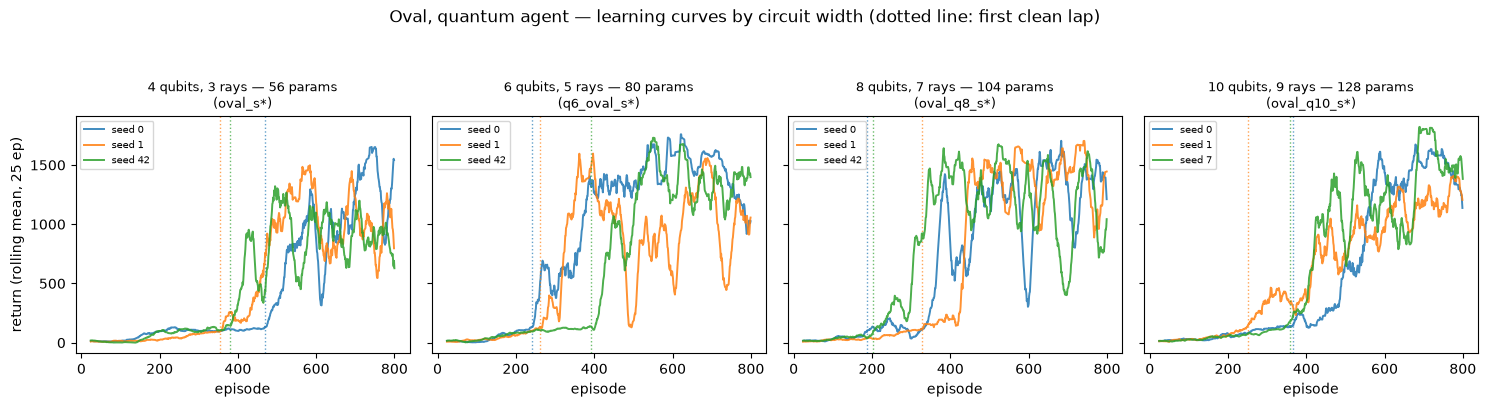

In [2]:
groups = [
    ("4 qubits, 3 rays — 56 params\n(oval_s*)", "oval_s*.history.json"),
    ("6 qubits, 5 rays — 80 params\n(q6_oval_s*)", "q6_oval_s*.history.json"),
    ("8 qubits, 7 rays — 104 params\n(oval_q8_s*)", "oval_q8_s*.history.json"),
    ("10 qubits, 9 rays — 128 params\n(oval_q10_s*)", "oval_q10_s*.history.json"),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, (title, pattern) in zip(axes, groups, strict=True):
    for d in load_runs(pattern):
        x, y = smooth(d["episode_returns"])
        (line,) = ax.plot(x, y, lw=1.4, alpha=0.85, label=f"seed {d['seed']}")
        if d.get("first_clean_episode"):
            ax.axvline(d["first_clean_episode"], color=line.get_color(),
                       ls=":", lw=1, alpha=0.7)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("episode")
    ax.legend(fontsize=7)
axes[0].set_ylabel("return (rolling mean, 25 ep)")
fig.suptitle("Oval, quantum agent — learning curves by circuit width "
             "(dotted line: first clean lap)", y=1.06)
fig.tight_layout()
plt.show()

## The scaling table

First-clean-lap episodes below are read from the histories just plotted; the
greedy columns are quoted from the campaign eval (4 standing-start episodes
per snapshot, deterministic policy, `fastsim`). Decision latency is per greedy
action on one laptop whose load varied between campaign waves — read trends,
not digits. The trend has a simple cause: exact simulation tracks $2^n$
amplitudes, so 4 → 10 qubits is 16 → 1024 numbers per forward pass.

In [3]:
# Greedy-eval columns quoted from the campaign results (not recomputed here).
EVAL = {  # qubits: (observation, params, greedy robustness, best lap s, ms/decision)
    4:  ("3 rays + speed", 56, "3/3 seeds lap greedily", 14.1, "~0.6"),
    6:  ("5 rays + speed", 80, "3/3 seeds lap greedily", 13.3, "0.6-1.0"),
    8:  ("7 rays + speed", 104, "3/3 seeds lap greedily", 13.3, "1.2-2.0"),
    10: ("9 rays + speed", 128, "3/3 seeds lap greedily", 12.0, "4.6-8.7"),
}
CAMPAIGN = {4: "oval_s*.history.json", 6: "q6_oval_s*.history.json",
            8: "oval_q8_s*.history.json", 10: "oval_q10_s*.history.json"}

print(f"{'qubits':>6}{'params':>8}  {'observation':<17}{'first clean lap (episode)':<27}"
      f"{'greedy laps':<26}{'best lap':>9}{'ms/dec':>9}")
for n, (obs, p, robust, best, ms) in EVAL.items():
    first = ", ".join(str(d["first_clean_episode"]) for d in load_runs(CAMPAIGN[n]))
    print(f"{n:>6}{p:>8}  {obs:<17}{first:<27}{robust:<26}{best:>8.1f}s{ms:>9}")

qubits  params  observation      first clean lap (episode)  greedy laps                best lap   ms/dec
     4      56  3 rays + speed   470, 354, 381              3/3 seeds lap greedily        14.1s     ~0.6
     6      80  5 rays + speed   242, 261, 392              3/3 seeds lap greedily        13.3s  0.6-1.0
     8     104  7 rays + speed   188, 327, 202              3/3 seeds lap greedily        13.3s  1.2-2.0
    10     128  9 rays + speed   366, 250, 358              3/3 seeds lap greedily        12.0s  4.6-8.7


What the campaign says:

- **Sample efficiency is flat.** Every width reaches its first clean lap in a
  few hundred episodes on the default schedule (4q 354–470, q6 242–392,
  q8 188–327, q10 250–366). Extra rays neither accelerate nor slow learning
  on the oval.
- **Lap times trend down — but the spreads overlap.** Bundled-driver laps of
  14.1 → 13.3 → 13.3 → 12.0 s across widths look like progress, and the
  10-qubit driver's 12.0 s is the fastest quantum lap in the demo; the
  three-seed spreads (13.5–14.1 / 12.9–13.3 / 12.5–13.3 / 12.0–14.2 s) say
  the headline is partly seed luck — q10's spread is the widest of any
  width. Robustness, at least, improved with the v2 recipe: every seed at
  every width laps greedily (the v1 campaign had outright 0/6 failures).
- **The cost grows anyway.** Greedy decision latency rises roughly an order of
  magnitude from 4 to 10 qubits. For a classical network an extra input scalar
  is nearly free; for a simulated quantum circuit each extra ray doubles the
  state.

So *more of the same input* scales the bill, and buys a tendency, not a
guarantee. Which raises the sharper question: can the same qubit budget buy a
**better** input?

## Engineered features: spend qubits on smarter observations

Besides rays and speed, the env can emit track-aware scalars (all normalized
to $[0, 1]$ — see `RacingEnv._obs`):

- **`curvature_ahead`** — tightest centerline curvature within the next 15
  units, relative to the track's maximum: *how sharp is the next corner?*
- **`lateral_offset`** — signed centerline offset in half-widths: *where am I
  between the walls?*
- **`heading_error`** — wrapped angle to the track tangent (0.5 = aligned):
  *am I pointing the right way?*
- **`corner_speed_ratio`** — current speed over the fastest speed the car can
  hold through the corner ahead (0.5 = exactly at the limit): *will I make
  it?*

The campaign's feature profiles trade rays for features at a fixed qubit
count, so parameter counts match the plain profiles exactly:

| profile | qubits | observation | params |
|---|---|---|---|
| `q6feat` | 6 | 3 rays + speed + `curvature_ahead` + `corner_speed_ratio` | 80 |
| `q8feat` | 8 | 3 rays + speed + all four features | 104 |
| `q10feat` | 10 | 5 rays + speed + all four features | 128 |

(The packaged `q6`/`q8`/`q10` config files carry these observations as
commented-out alternatives you can enable.)

### Where `corner_speed_ratio` comes from

The car turns at $\dot\theta = \text{steer} \cdot k_\text{steer} \cdot f(v)$,
where the steering-authority falloff
$f(v) = 2\,v\,v_\text{turn} / (v_\text{turn}^2 + v^2)$ peaks at
$v = v_\text{turn}$ and fades at speed. Holding a circle of radius $R$
requires $\dot\theta = v / R$, so full lock ($\text{steer} = 1$) holds the
corner only while

$$\frac{v}{R} \;\le\; \frac{2\,k_\text{steer}\,v\,v_\text{turn}}{v_\text{turn}^2 + v^2}
\quad\Longleftrightarrow\quad
v \;\le\; v_\text{safe}(R) = \sqrt{2\,k_\text{steer}\,v_\text{turn}\,R - v_\text{turn}^2}.$$

`corner_speed_ratio` is $v / v_\text{safe}(R_\text{ahead})$ — the one number a
racing line cares about, handed to the circuit instead of hoping it
reconstructs the physics from raw rays.

In [4]:
from traqmania.config import load_config

phys = load_config()["physics"]
k_steer, v_turn = phys["k_steer"], phys["v_turn"]
print(f"k_steer={k_steer}, v_turn={v_turn}, v_max={phys['v_max']}")
print(f"tightest holdable corner: R = v_turn / (2 k_steer) = {v_turn / (2 * k_steer):.2f} units")
for radius in (2, 5, 10, 20, 40):
    v_safe = np.sqrt(max(0.0, 2 * k_steer * v_turn * radius - v_turn**2))
    print(f"  R = {radius:>2} units -> v_safe = {v_safe:5.1f}"
          + ("  (> v_max: flat out is fine)" if v_safe > phys["v_max"] else ""))

k_steer=2.6, v_turn=9.0, v_max=25.0
tightest holdable corner: R = v_turn / (2 k_steer) = 1.73 units
  R =  2 units -> v_safe =   3.5
  R =  5 units -> v_safe =  12.4
  R = 10 units -> v_safe =  19.7
  R = 20 units -> v_safe =  29.2  (> v_max: flat out is fine)
  R = 40 units -> v_safe =  42.3  (> v_max: flat out is fine)


### Oval: plain rays vs engineered features, same qubit budget

Same track, same schedule, same parameter count — only the observation
changes.

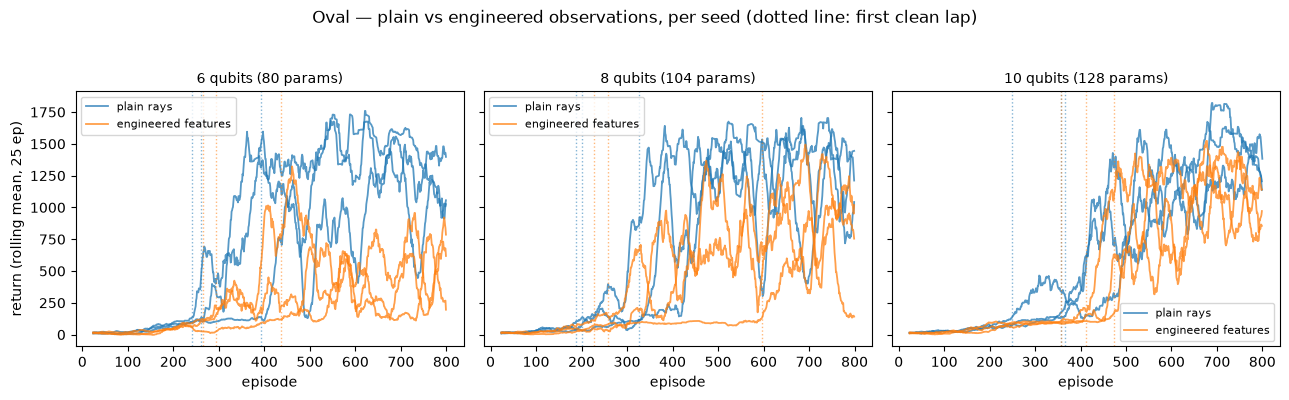

In [5]:
pairs = [
    ("6 qubits (80 params)", "q6_oval_s*.history.json", "featoval_q6_s*.history.json"),
    ("8 qubits (104 params)", "oval_q8_s*.history.json", "featoval_q8_s*.history.json"),
    ("10 qubits (128 params)", "oval_q10_s*.history.json", "featoval_q10_s*.history.json"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, (title, plain_pat, feat_pat) in zip(axes, pairs, strict=True):
    for pat, color, label in ((plain_pat, "C0", "plain rays"),
                              (feat_pat, "C1", "engineered features")):
        for i, d in enumerate(load_runs(pat)):
            x, y = smooth(d["episode_returns"])
            ax.plot(x, y, color=color, lw=1.3, alpha=0.75,
                    label=label if i == 0 else None)
            if d.get("first_clean_episode"):
                ax.axvline(d["first_clean_episode"], color=color, ls=":", lw=1, alpha=0.55)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("episode")
    ax.legend(fontsize=8)
axes[0].set_ylabel("return (rolling mean, 25 ep)")
fig.suptitle("Oval — plain vs engineered observations, per seed "
             "(dotted line: first clean lap)", y=1.04)
fig.tight_layout()
plt.show()

In [6]:
# Greedy campaign eval, quantum agents: per-seed laps @ best lap (seed order 0/1/42
# unless noted). Quoted from the campaign results.
rows = [
    ("oval",    "q6  plain",  "bundled winner (seed 42): 24 laps over 8 eps @ 14.7s",       14.7),
    ("oval",    "q6  feat",   "6/6 @ 13.7s, 4/6 @ 13.8s, 6/6 @ 13.8s",                      13.7),
    ("oval",    "q8  plain",  "0/6, 6/6 @ 14.5s, 6/6 @ 16.3s, 6/6 @ 14.0s, 6/6 @ 16.2s"
                              " (seeds 0/1/7/42/123)",                                       14.0),
    ("oval",    "q8  feat",   "6/6 @ 13.9s, 6/6 @ 13.6s, 6/6 @ 13.8s",                      13.6),
    ("oval",    "q10 plain",  "6/6 @ 14.8s, 6/6 @ 16.2s, 6/6 @ 13.7s, 3/6 @ 16.1s"
                              " (seeds 0/1/7/42)",                                           13.7),
    ("oval",    "q10 feat",   "1/6 @ 14.2s, 6/6 @ 14.2s (seeds 0/42)",                      14.2),
    ("chicane", "q6  plain",  "5/6 @ 14.3s, 3/6 @ 14.7s, 6/6 @ 14.8s",                      14.3),
    ("chicane", "q6  feat",   "5/6 @ 15.8s, 6/6 @ 13.9s, 6/6 @ 15.7s",                      13.9),
]
print(f"{'track':<9}{'config':<11}{'greedy laps @ best lap, per seed':<66}{'best':>6}")
for track, cfg, per_seed, best in rows:
    print(f"{track:<9}{cfg:<11}{per_seed:<66}{best:>5.1f}s")

track    config     greedy laps @ best lap, per seed                                    best
oval     q6  plain  bundled winner (seed 42): 24 laps over 8 eps @ 14.7s               14.7s
oval     q6  feat   6/6 @ 13.7s, 4/6 @ 13.8s, 6/6 @ 13.8s                              13.7s
oval     q8  plain  0/6, 6/6 @ 14.5s, 6/6 @ 16.3s, 6/6 @ 14.0s, 6/6 @ 16.2s (seeds 0/1/7/42/123) 14.0s
oval     q8  feat   6/6 @ 13.9s, 6/6 @ 13.6s, 6/6 @ 13.8s                              13.6s
oval     q10 plain  6/6 @ 14.8s, 6/6 @ 16.2s, 6/6 @ 13.7s, 3/6 @ 16.1s (seeds 0/1/7/42) 13.7s
oval     q10 feat   1/6 @ 14.2s, 6/6 @ 14.2s (seeds 0/42)                              14.2s
chicane  q6  plain  5/6 @ 14.3s, 3/6 @ 14.7s, 6/6 @ 14.8s                              14.3s
chicane  q6  feat   5/6 @ 15.8s, 6/6 @ 13.9s, 6/6 @ 15.7s                              13.9s


Under the v1 physics this comparison produced the notebook's most-quoted
result: features looked like a clear win at 6–8 qubits. The v2 three-seed
spreads dissolve it. Feature and plain ranges overlap at every width —
q6feat 13.0–13.6 s vs plain q6 12.9–13.3 s, q8feat 12.5–13.8 s vs plain q8
12.5–13.3 s (the seed-42 q8feat run's 12.5 s *looked* like the old story
until the other seeds came in), q10feat 12.5–13.5 s vs plain q10
12.0–14.2 s. Sample efficiency is unchanged either way — first laps still
arrive after a few hundred episodes. On the v2 oval, a well-tuned recipe
makes the observation design a wash: no free lunch, in either direction.

### The honest failure that wasn't: gp above 4 qubits

This section has now been rewritten twice, and the history is the lesson.
The **4-qubit** driver (3 rays) handles gp, the hardest track — the bundled
`quantum_gp` weights greedy-lap it at 23.2 s, and that itself took an
overnight recipe sweep (see `docs/SCIENCE.md`). The first scaling campaign
suggested more qubits *couldn't* follow: plain `q6`, `q6feat`, `q8feat`,
`q10feat` and combo at q6/q8/q10 all finished with **zero greedy laps**
under v2 (curves below — they lap during $\varepsilon$-greedy exploration,
then converge to deterministic policies that crash).

But those runs all used the *old* fast epsilon decay (1200 of 2000
episodes) — the same recipe that fails at 4 qubits too. A follow-up
campaign re-ran the identical configurations with the swept winning recipe
(decay over 2000 of 3000 episodes), and **gp now laps greedily at every
qubit count**. The 36-episode reliability evals: q6feat 27/36 episodes
(slow, mean 41.5 s), q8feat 18/36 (mean 40.2 s), and q10feat **25/36 with
mean 22.3 s / best 20.0 s** — pace-competitive with the bundled 4-qubit
driver (29/36, mean 23.9 s, best 20.4 s), from one training seed. The
cautionary tale is q6-plain: an 18.1 s lap on the quick 4-episode
training eval that collapsed to 5/36 under the full check, with seeds 0/1
giving 1 and 0 laps — exactly the selection effect this notebook keeps
warning about. Combo stays the holdout: fresh 4-qubit combo laps for the
first time with the slow decay (23/36, mean 38.1 s), but above 4 qubits
combo never laps greedily under any strategy tried.

The lesson is now sharper than the original: what fixes gp is not more
qubits and not a smarter observation but a better *recipe* — and once the
recipe is right, capacity scales cleanly to 10 qubits. Exploration was
the constraint all along. The q10 winner ships as `quantum_gp_q10.npz`:
weight sidecars now record the observation they were trained with and the
server adopts it per driver, so the feature-observation gp driver coexists
with the plain-rays oval/chicane weights at 10 qubits. The q6/q8 gp
candidates stay unbundled (they lap, but ~17 s off the pace).


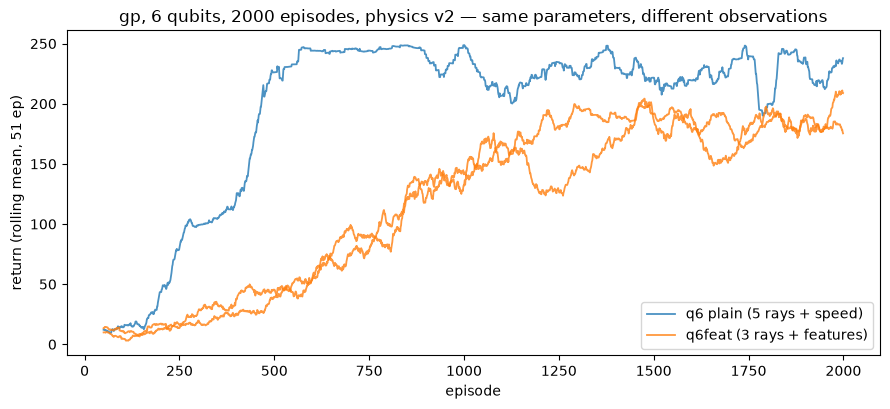

greedy eval on gp, physics v2 (36-episode reliability protocol):
  old recipe (decay 1200/2000 eps): q6 plain, q6feat, q8feat, q10feat -> 0 laps everywhere
  winning recipe (decay 2000/3000 eps):
    q6feat  : 27/36 episodes lap, mean 41.5s
    q8feat  : 18/36 episodes lap, mean 40.2s
    q10feat : 25/36 episodes lap, mean 22.3s, best 20.0s
    4q ref  : 29/36 episodes lap, mean 23.9s, best 20.4s  (bundled quantum_gp)


In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))
for pat, color, label in (("gp_q6_s*.history.json", "C0", "q6 plain (5 rays + speed)"),
                          ("featgp_q6_s*.history.json", "C1", "q6feat (3 rays + features)")):
    for i, d in enumerate(load_runs(pat)):
        x, y = smooth(d["episode_returns"], window=51)
        ax.plot(x, y, color=color, lw=1.3, alpha=0.8, label=label if i == 0 else None)
        if d.get("first_clean_episode"):
            ax.axvline(d["first_clean_episode"], color=color, ls=":", lw=1, alpha=0.55)
ax.set_xlabel("episode")
ax.set_ylabel("return (rolling mean, 51 ep)")
ax.set_title("gp, 6 qubits, 2000 episodes, physics v2 — same parameters, different observations")
ax.legend()
fig.tight_layout()
plt.show()

print("greedy eval on gp, physics v2 (36-episode reliability protocol):")
print("  old recipe (decay 1200/2000 eps): q6 plain, q6feat, q8feat, q10feat -> 0 laps everywhere")
print("  winning recipe (decay 2000/3000 eps):")
print("    q6feat  : 27/36 episodes lap, mean 41.5s")
print("    q8feat  : 18/36 episodes lap, mean 40.2s")
print("    q10feat : 25/36 episodes lap, mean 22.3s, best 20.0s")
print("    4q ref  : 29/36 episodes lap, mean 23.9s, best 20.4s  (bundled quantum_gp)")

### Making qubits matter: the follow-up mechanisms, measured

If exploration was the constraint, what would make the *extra* qubits pay?
A follow-up analysis pinned four bottlenecks — the 4-action bang-bang
interface, a sensing horizon shorter than the braking distance (~17 m to
brake from `v_max`, 15 m lookahead), a reward that never asks for speed,
and lucky-lap snapshot selection — and the stack now has a mechanism for
each: a **qubit-scaled action readout** (`[circuit] n_actions`: 6/8 actions
read as $Q_a = \langle Z_a\rangle$ off the first $k$ qubits, adding trail
braking and half-steer), **multi-horizon curvature features**
(`"curvature_ahead:30"`), a **pace fine-tune phase** (`--pace`:
per-decision time penalty at low epsilon), and **12-episode
reliability-first snapshot selection**. One campaign later (single seed,
36-episode greedy evals), the honest scoreboard:

- **Pace fine-tuning is the clear win.** 600 pace episodes moved the
  bundled 10-qubit gp driver from 25/36 lapped @ 22.3 s mean / 20.0 s best
  to 14/36 @ **20.2 s mean / 17.5 s best** — the first greedy quantum gp
  lap under 18 s (hero ceiling: 16.4 s). The steadier 20.0 s driver stays
  bundled; pace came at a real reliability cost.
- **Scaled actions work mechanically but don't converge yet.** The
  8-action q10 driver drove an **18.9 s** gp lap *during exploration* —
  the fastest quantum lap this project has recorded — yet no scaled-action
  lane lapped greedily (the 4-action control on the *same* observation:
  29/36 at q8). On the flat-out oval, 6 actions lap 36/36 but ~1.5 s
  *slower* than 4 actions: extra actions only have value where braking
  matters, and they enlarge the exploration problem everywhere. The
  untried recipe: warm-start the widened head from a trained 4-action
  policy (the action tables are prefix-compatible on purpose).
- **Seeing farther didn't help (yet).** The κ@15/30/50 braking ladder is
  learnable at q8 but converged *worse* at q10 (1/36) than the mixed
  features above (25/36) — a null result, reported as one.
- **Selection kept its promise, with one tension.** No campaign snapshot's
  36-episode recheck contradicts its 12-episode eval — the 18.1 s-style
  mirage is gone. But inside a *pace* phase, reliability-first ranking is
  the wrong preference (the 4-qubit pace run finished a perfect 36/36
  while giving back 4 s of mean lap); pace phases want "fastest mean above
  a reliability floor".


### Do features help everyone? The MLP control

If the engineered observation simply made the task easier, the matched MLP
baseline (same observations, 92 parameters, ~0.01 ms/decision) should improve
too. It doesn't:

In [8]:
# Greedy-eval columns quoted from the campaign; first-clean episodes computed
# from the shipped histories (physics v2, seed order 0/42).
mlp_rows = (
    ("rays (5 + speed)", "mlp_oval_q6_s*.history.json",
     "16 laps @ 12.1s, 16 laps @ 12.5s"),
    ("engineered (q6feat)", "mlp_featoval_q6_s*.history.json",
     "16 laps @ 12.9s, 16 laps @ 13.0s"),
)
print(f"{'MLP observation':<22}{'first clean lap (episode)':<28}{'greedy laps @ best lap':<42}")
for label, pattern, evals in mlp_rows:
    firsts = ", ".join(str(d["first_clean_episode"]) for d in load_runs(pattern))
    print(f"{label:<22}{firsts:<28}{evals:<42}")

MLP observation       first clean lap (episode)   greedy laps @ best lap                    
rays (5 + speed)      135, 150                    16 laps @ 12.1s, 16 laps @ 12.5s          
engineered (q6feat)   148, 151                    16 laps @ 12.9s, 16 laps @ 13.0s          


The MLP is at 12.1–12.5 s from raw rays and slightly *slower* with features
(12.9–13.0 s), while learning no faster — directionally the same mild
penalty as under v1, and the only remnant of what once looked like an
asymmetry. With the quantum side's feature advantage dissolved by the v2
seed spreads, there is no longer a "features help the VQC and not the MLP"
story to explain — and we say so rather than keep the intrigue alive.
Single-seed asymmetries in small RL benchmarks usually are noise; ours was.
Keep the epistemics straight either way: **one environment, two to three
seeds per variant, features hand-built for this exact car model.**

## Does any of this survive shots?

Everything above used the exact statevector.
[Notebook 05](05_real_quantum_hardware.ipynb) covers real hardware; here is
the campaign's 1024-shot Aer sanity check of two sensor-scaling snapshots
(same greedy protocol, numbers quoted — nothing executes on hardware in this
notebook). One label: this check was run on **v1-physics campaign
snapshots** and has not been repeated for the v2 drivers; the qualitative
points below are what carry over.

In [9]:
# Quoted from the v1-physics campaign's shot check (not re-run under v2).
print(f"{'snapshot (v1)':<16}{'exact fastsim':<30}{'Aer, 1024 shots':<30}")
print(f"{'oval q8, s1':<16}{'6/6 laps, 14.5s, ~1.7 ms/dec':<30}{'6/6 laps, 14.5s, ~18 ms/dec':<30}")
print(f"{'oval q10, s42':<16}{'3/6 laps, 16.1s, ~8.7 ms/dec':<30}"
      f"{'3/6 laps, 16.1s, ~24 ms/dec':<30}")

snapshot (v1)   exact fastsim                 Aer, 1024 shots               
oval q8, s1     6/6 laps, 14.5s, ~1.7 ms/dec  6/6 laps, 14.5s, ~18 ms/dec   
oval q10, s42   3/6 laps, 16.1s, ~8.7 ms/dec  3/6 laps, 16.1s, ~24 ms/dec   


The robust 8-qubit policy was unchanged by 1024-shot sampling — its Q-value
gaps are wide enough that sampling noise doesn't flip action choices — while
the marginal 10-qubit snapshot stayed exactly as marginal under shots as
under exact simulation. Shot noise, in other words, respects the policy's
existing margins rather than adding a new failure mode. The real casualty is
latency: 18–24 ms per decision starts to eat into a 10 Hz control budget
before any real-device queue or noise enters the picture. (Both snapshots
are v1-physics; the v2 drivers' margins have not been shot-audited.)

## What this shows — and what it doesn't

Same rules as [notebook 04](04_training_the_quantum_driver.ipynb): honesty
over excitement.

- **Parity, still not advantage.** Every quantum result here is matched or
  beaten by a tiny MLP at roughly 1/100th the decision latency (best oval
  laps: MLP 11.9–12.1 s at the q10 observation vs quantum's 12.0 s — the
  closest the two stacks have ever been, and still parity). This campaign
  characterizes *how a small VQC scales*; it demonstrates no quantum
  usefulness, and none should be inferred.
- **More qubits bought a tendency, not a guarantee.** Flat sample
  efficiency, bundled laps trending 14.1 → 12.0 s while the three-seed
  spreads overlap, and exponentially growing simulation cost.
- **The hard tracks needed a recipe, not qubits.** With the old fast
  epsilon decay, gp fails greedily at q6/q8/q10 with every observation;
  with the swept slow decay it laps at every size, and q10feat is
  pace-competitive with the bundled 4-qubit driver (one seed) — it now
  ships as `quantum_gp_q10.npz`, driving under its own recorded
  observation. Combo above 4 qubits stays unsolved, and the slow q6/q8
  gp candidates stay unbundled. What fixed 4-qubit gp was a swept training recipe — an honest
  scaling limitation plus an honest rescue, in the recipe rather than the
  architecture.
- **Faster laps came from the objective, not the register.** The
  follow-up mechanisms campaign (above) moved the 10-qubit gp best
  from 20.0 s to 17.5 s with a lap-time-shaped fine-tune, while the
  scaled action sets — despite an 18.9 s exploration lap — have not
  yet produced a converged greedy driver. Single seed; treat
  accordingly.
- **The v1 feature asymmetry dissolved.** Under v2, with three seeds per
  variant, engineered features neither help the VQC nor meaningfully hurt
  the MLP. We reported the dissolution as prominently as the original
  observation — that is the epistemics working, not failing.
- **Watch the selection effects.** "Best greedy lap" columns favor whichever
  variant had more evaluated snapshots; the per-seed robustness columns are
  the ones that carry information.

## Outlook: one driver, any track — measured

The bundled 4-qubit weights already hint at transfer: the gp-trained
specialist zero-shot greedy-laps the oval (13.5 s) and even combo (40.6 s),
though not the chicane — the hard track teaches transferable driving in a
way the easy ones don't (oval/chicane specialists transfer to each other but
fail gp outright).

The universal-driver campaign (histories `uni2_*` in `data/histories/`)
trained single drivers on all four tracks round-robin under v2, 3000
episodes each:

- **Fresh multi-track training** (seeds 42, 0, 1, 7; one 5000-episode run):
  the best laps oval/chicane and 9–10/10 generated tracks but **fails gp and
  combo outright** — the same braking problem as single-track gp training.
- **Warm migration** — fine-tuning the v1 universal driver under the v2
  physics — produced the bundled **`quantum_universal.npz`**: oval 13.0 s,
  chicane 13.3 s, gp 30.3 s, combo 52.3 s, and 10/10 unseen generated tracks
  at difficulty 0.5. Seed-honesty: re-running that same migration at seeds 0
  and 1 collapses to an *oval specialist* (12.1 s ovals, nothing else) —
  one seed in three kept full coverage, and that is the seed that ships.

So a 4-qubit circuit *can* be a universal driver — when the hard tracks are
in the training mix, the starting point already knows how to brake, and the
seed cooperates. In the demo, the universal weights drive every 🎲 surprise
track (and every ✏️ drawn one), and the Watch-mode driver picker lets you
race any specialist on any track to see the transfer, and its limits, live.